In [33]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
msa_dir_path = '../data/genes/mmseqs/'

def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


# Cluster analysis: **cluster_8**

In [19]:
cluster_id = 8

In [20]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == cluster_id)].copy()

# Write the protein sequences to a FASTA file and create an MSA. 
msa_path = f'../data/genes/cluster_{cluster_id}.afa'
FASTAFile.from_df(genes_df).write(f'../data/genes/cluster_{cluster_id}.faa')
if not os.path.exists(msa_path):
    subprocess.run(f'muscle -align ../data/genes/cluster_{cluster_id}.faa -output {msa_path}', shell=True, check=True)
msa = MSAFile.from_file(msa_path)

print('Number of genes:', len(genes_df))
print('Maximum length:', genes_df.seq.apply(len).max())
print('Minimum length:', genes_df.seq.apply(len).min())

print()
print(str(FASTAFile.from_df(genes_df)))

Number of genes: 9
Maximum length: 69
Minimum length: 53

>orfm.bz_0.1_54
MYHLLDNKKFLDEIFKIDINELRIALYKKYERKDIAEKLNISDVQVTRKLRGQSPITFTEFKLLIEMIK
>orfm.bz_1.1_21
MEISILRKKLYERYTRKQLSELLNVSETQISRLLNSHSILNVNQYLFLKNLLE
>orfm.bz_2.1_142
MLSIDEIFNTNINDLRNTLYSNYSRQEIADKLNLSVVQVSRLLNGNSIISYKQFLILKEMIKK
>orfm.bz_3.1_169
MMIRIDELKKKLYEVYKPSYIAKILNVSNNQVYRLLNGKSEMNITQYNTLIELIEKKE
>orfm.bz_4.1_69
MLDLKELREKLKKKYDVKDISKKLNLCRVQTSRILNGHAVLSIDRYKILEDMLK
>orfm.bz_8.1_70
MNNEIKEIFDTNINELRKELYKKYTRKQIADELKISKRQVSMLLNGKSMLSYKQYLILKQMLKSYTII
>orfm.bz_9.1_173
MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGKSIISYKQFLILKDMIK
>orfm.bz_10.1_121
MEHLSLYELKDILLKKYTRKYLADKLEISEQQLYRILNRKNNMTLIQYEKLLTLI
>orfm.bz_11.1_163
MMEQFNYTEKTNDLREKLYLKYNRKQLSDILKVSENHVSRLLNNQSHMTIYQYFTLLELIK



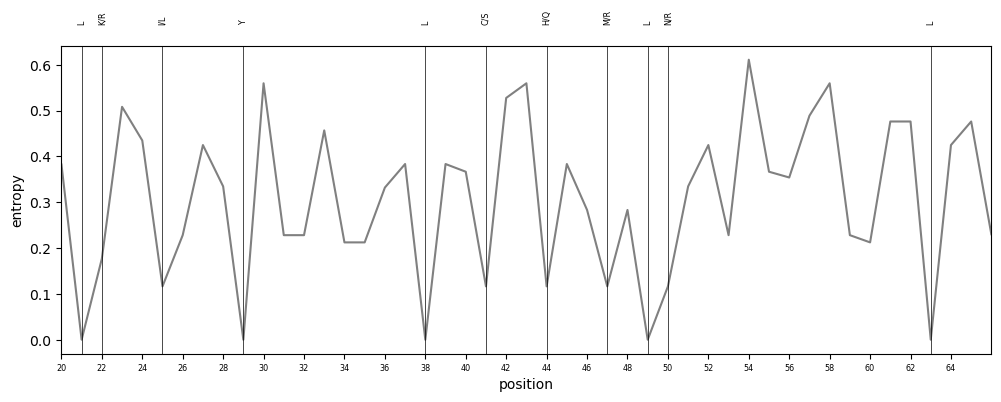

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_entropy(msa, ax=ax, annotate=True, x_max=66)
plt.show()

## Oligomerization 

The pairwise protein-protein interaction data indicates that cluster_8 proteins interact with themselves. Based on the Foldseek search hits, it is likely that these are transcription factors, which often dimerize [[Fernandez-Lopez et. al. 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9723621)], though some form higher-order oligomers (mainly, tetramers). 

In order to evaluate the likely oligomerization state and identify the DNA-contacting residues of the cluster_8 proteins, we co-fold 1, 2, and 4 copies of cluster_8 proteins from each genome with a random 50 bp DNA duplex. 

The oligomerization state of the transcriptional regulator could provide some indication of the type of DNA motif it recognizes. For example, dimeric transcription factors often recognize direct or inverted repeats [[Fernandez-Lopez et. al. 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9723621)]. Tetrameric transcriptional regulators, e.g. TtgV, might recognize adjacent sites [[Lu et. al. 2010](https://pmc.ncbi.nlm.nih.gov/articles/PMC2975931/)]. However, it should be noted that some dimers bind asymmetric sequences, and some monomeric HTH proteins recognize inverted repeats through other arrangements.



In [29]:
nt_seq_forward = 'ATGCGTACGTTAGCTAGGCTACGATCGTACGGTACCTAGCTGACGTA'
nt_seq_reverse = get_reverse_complement(nt_seq_forward)

In [30]:
alphafold_input_dir = f'../data/genes/alphafold/af_input/cluster_8'
alphafold_output_dir = f'../data/genes/alphafold/af_output/cluster_8' 
os.makedirs(alphafold_input_dir, exist_ok=True)

# Configure the AlphaFold3 job, using fewer diffusion samples and recycles to reduce runtime. 
alphafold_params = dict()
alphafold_params['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
alphafold_params['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 

In [31]:
msas = get_msas_unpaired(genes_df.index)

print('Number of genes with custom MSAs:', len(msas))
assert len(msas) == len(genes_df), f'All of the conserved gene clusters should have a custom MSA in {msa_dir_path}'

Number of genes with custom MSAs: 9


In [32]:
for num_subunits in [1, 2, 4]: # The most likely oligomerization states. 
    for row in genes_df.itertuples():

        name = f'{row.Index}_{num_subunits}mer-dsdna'
        input = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=3, version=2) # Use 3 seeds rather than the default 5 to reduce runtime.

        unpaired_msa = msas.get(row.Index, None)
        paired_msa = '' if (unpaired_msa is not None) else None
        input.add_seq(row.seq, paired_msa=paired_msa, unpaired_msa=unpaired_msa)
        input.add_seq(nt_seq_forward, chain_type='dna')
        input.add_seq(nt_seq_reverse, chain_type='dna')

        input.write(os.path.join(alphafold_input_dir, f'{name}.json'))

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(alphafold_input_dir)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in alphafold_params.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_8/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 5"


## Foldseek search 

Structures generated using the custom MSAs were used to query PDB, UniProt, SwissProt, and BFVD. 

1. **PAS and DNA binding domain containing protein:** The PAS domain is usually a sensory domain, and can bind small molecules, cofactors, or respond to environmental signals and alter the conformation or oligomerization of the protein. Accompanied by a DNA-binding domain, proteins in this category are likely transcription factor.

2. **Germin-like protein:** They are primarily cupin-fold proteins, and their functions are diverse. They are generally metal-binding (apparently some bind manganese). One example is Mn-dependent oxalate oxidase, which also registered as a Foldseek hit.

3. **HTH-type transcriptional regulator:**

4. **XRE-type transcriptional regulator:**

5. **LexA-type transcriptional regulator:**

6. **Transcriptional regulator:**

7. **Cytosine-specific methyltransferase:** The hits to the cytosine-specific methyltransferases start at the extreme N-terminus and cover the first N-terminal amino acids. Examination of one of the hits (A0A2A2EGU0) indicates that the protein has hits for HTH_XRE and lambda repressor-like DNA-binding domain, so these structural matches are likely due to the HTH motif.

8. **HicB antitoxin:** Part of the HicAB toxin-antitoxin system. It binds HicA itself, and also binds the DNA upstream of the HicA operon to suppress transcription. 

In [23]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)].copy()

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
filters['short_alignment'] = foldseek_search_df.alignment_length < 100

foldseek_search_df = apply_filters(filters, foldseek_search_df)

apply_filters: 3434 entries removed by low_tm_score.
apply_filters: 18753 entries removed by short_alignment.


In [24]:
categories = dict()
categories['PAS and DNA binding domain containing protein'] = foldseek_search_df.target_header.str.contains('PAS and DNA binding domain containing protein', case=False) 
categories['germin-like protein'] = foldseek_search_df.target_header.str.contains('germin|oxalate oxidase', case=False) 
categories['HTH-type transcriptional regulator'] = foldseek_search_df.target_header.str.contains('HTH|helix-turn-helix', case=False) 
categories['XRE-type transcriptional regulator'] = foldseek_search_df.target_header.str.contains('XRE|BetR', case=False) 
categories['LexA-type transcriptional regulator'] = foldseek_search_df.target_header.str.contains('LexA', case=False) 
categories['transcriptional regulator'] = foldseek_search_df.target_header.str.contains('transcriptional regulator', case=False) 
categories['cytosine-specific methyltransferase'] = foldseek_search_df.target_header.str.contains('Cytosine-specific methyltransferase', case=False)
categories['HicB antitoxin'] = foldseek_search_df.target_header.str.contains('HicB', case=False)

foldseek_search_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')


Based on the Foldseek search results, it seems that the cluster_8 gene encodes a helix-turn-helix transcriptional regulator. This suggests that it binds a specific DNA motif. Given its conserved position at the start of what appears to be the Betazoid replication cluster, it is likely this site is somewhere in the region upstream of this cluster.

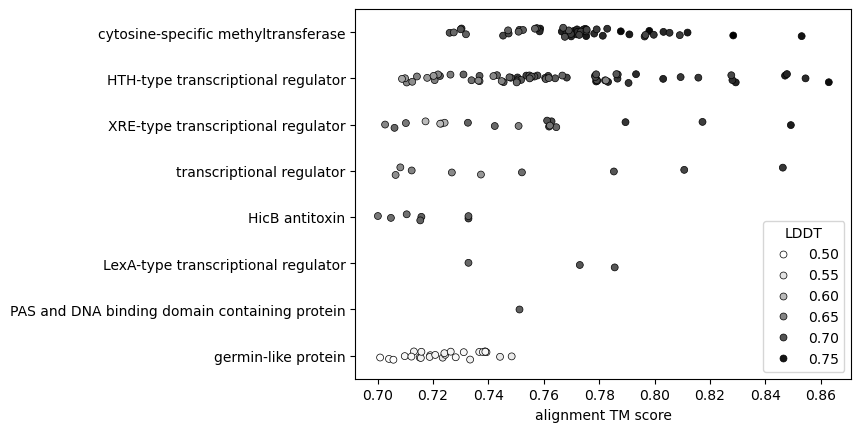

In [25]:
fig, ax = plt.subplots()

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized', 'paired box protein'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')
plt.show()